In [1]:
pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# 📊 Phase 3 — Exploratory Data Analysis (EDA)
### SoundMetrics B2C Music SaaS — Customer Segmentation Project
**Author:** Radheshyam

---

## What is EDA?

EDA means **exploring your data visually and statistically before building any models**.
It answers the question: *'What story is this data telling me?'*

As a data analyst, EDA is where you go from raw numbers to **business insights**.
Every chart in this notebook answers a real business question that a SoundMetrics
product manager or CEO would actually ask.

---

## Business Questions We Will Answer

| # | Question | Why It Matters |
|---|---|---|
| 1 | How has our user base grown over time? | Measures business health |
| 2 | Which countries are our biggest markets? | Informs regional strategy |
| 3 | How do users discover us? | Helps optimise marketing spend |
| 4 | What is our plan distribution? | Revenue mix analysis |
| 5 | What are peak listening hours? | Helps schedule server capacity |
| 6 | Which genres are most popular? | Guides content licensing deals |
| 7 | Which devices do users prefer? | Informs product team priorities |
| 8 | How does listening vary by month? | Seasonal planning |
| 9 | What does our revenue trend look like? | Finance reporting |
| 10 | How healthy is our payment success rate? | Billing team KPI |
| 11 | What are the most common support issues? | Customer success priorities |
| 12 | How does CSAT vary by user segment? | Service quality analysis |
| 13 | How do behaviour segments compare? | Foundation for segmentation |

---

## 0️⃣ Setup — Libraries, Settings & Load Data

We import all libraries at the top — this is best practice.
Never scatter imports throughout a notebook.

In [2]:
# ── Core data libraries ───────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation libraries ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Built-in Python libraries ─────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # suppress minor warnings

# ── Chart style settings ──────────────────────────────────
# These 4 lines make ALL charts in this notebook look professional
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize']  = (12, 5)    # default chart size
plt.rcParams['figure.dpi']      = 120         # sharpness
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 11

# ── Pandas display settings ───────────────────────────────
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [3]:
# ── Load cleaned data ─────────────────────────────────────
# We always use cleaned data for analysis, never raw data
CLEAN_DIR = 'data/cleaned'

users   = pd.read_csv(f'{CLEAN_DIR}/users_clean.csv',            parse_dates=['signup_date'])
subs    = pd.read_csv(f'{CLEAN_DIR}/subscriptions_clean.csv',    parse_dates=['start_date','end_date'])
events  = pd.read_csv(f'{CLEAN_DIR}/listening_events_clean.csv', parse_dates=['event_date'])
pays    = pd.read_csv(f'{CLEAN_DIR}/payments_clean.csv',         parse_dates=['payment_date'])
tickets = pd.read_csv(f'{CLEAN_DIR}/support_tickets_clean.csv',  parse_dates=['created_date','resolved_date'])

print('Loaded tables:')
for name, df in [('users',users),('subscriptions',subs),('listening_events',events),
                  ('payments',pays),('support_tickets',tickets)]:
    print(f'  {name:<22} {len(df):>10,} rows  x  {df.shape[1]} cols')

Loaded tables:
  users                      99,500 rows  x  10 cols
  subscriptions             100,000 rows  x  10 cols
  listening_events        1,186,834 rows  x  10 cols
  payments                   72,730 rows  x  9 cols
  support_tickets            20,000 rows  x  9 cols


---
## 1️⃣ User Growth Over Time

**Business Question:** How has our user base grown month by month?

This is one of the first charts any startup CEO looks at.
We will show both **monthly new signups** and **cumulative total users**.

In [4]:
# ── Monthly signups ───────────────────────────────────────
# dt.to_period('M') converts a date like 2022-03-15 → '2022-03'
# This groups all signups in the same month together

users['signup_month'] = users['signup_date'].dt.to_period('M')
monthly_signups = (
    users.groupby('signup_month')
         .size()
         .reset_index(name='new_users')
)
monthly_signups['signup_month'] = monthly_signups['signup_month'].astype(str)

# Cumulative sum = running total of all users over time
monthly_signups['total_users'] = monthly_signups['new_users'].cumsum()

print(monthly_signups.tail())

   signup_month  new_users  total_users
67      2024-08       1411        94010
68      2024-09       1324        95334
69      2024-10       1435        96769
70      2024-11       1363        98132
71      2024-12       1368        99500


FileNotFoundError: [Errno 2] No such file or directory: 'data/charts/01_user_growth.png'

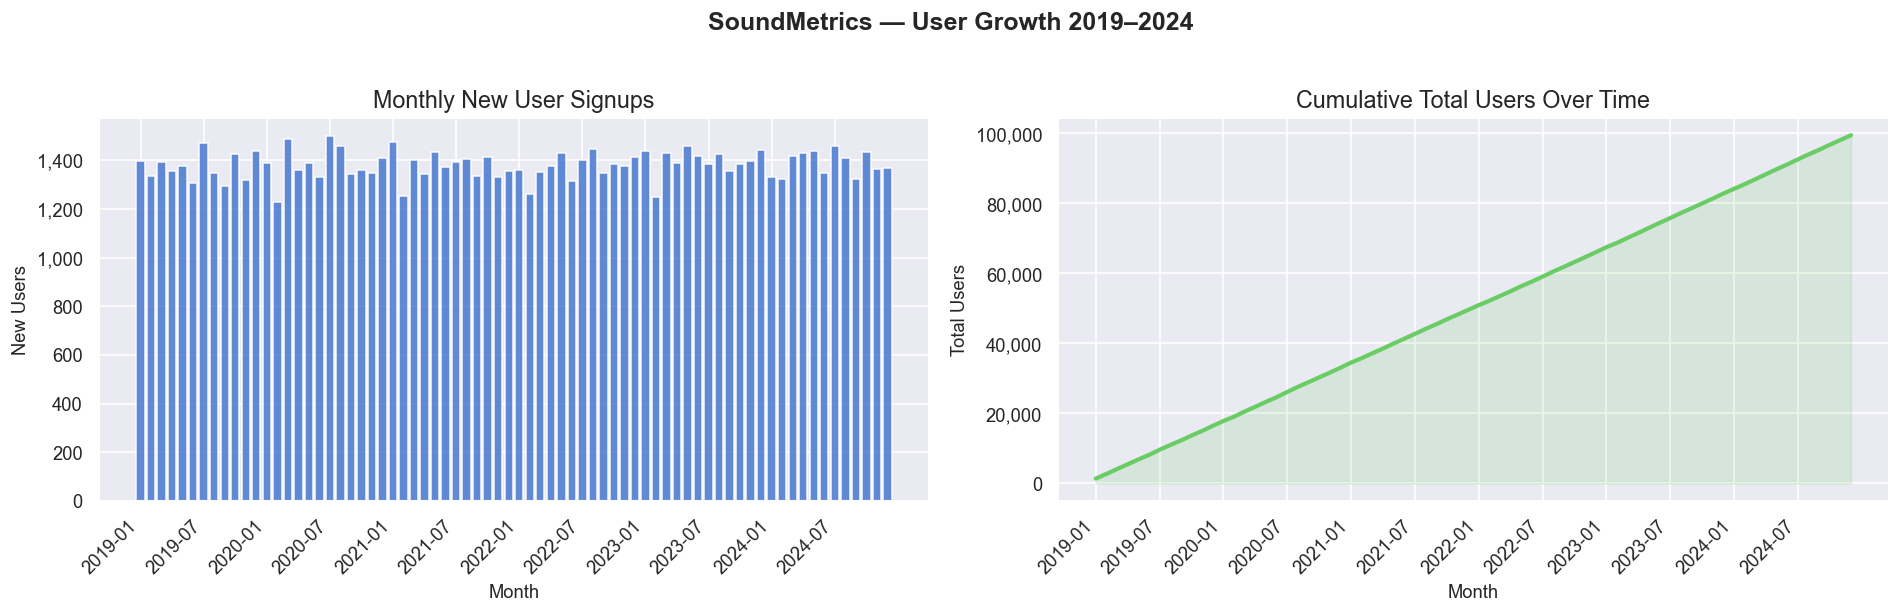

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Monthly new signups (bar chart) ──────────────
# We only label every 6th month on x-axis so it doesn't get crowded
x_labels = monthly_signups['signup_month'].tolist()
tick_positions = range(0, len(x_labels), 6)
tick_labels    = [x_labels[i] for i in tick_positions]

axes[0].bar(range(len(x_labels)), monthly_signups['new_users'],
            color=sns.color_palette('muted')[0], alpha=0.85)
axes[0].set_xticks(list(tick_positions))
axes[0].set_xticklabels(tick_labels, rotation=45, ha='right')
axes[0].set_title('Monthly New User Signups')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('New Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Chart 2: Cumulative user growth (line chart) ──────────
axes[1].plot(range(len(x_labels)), monthly_signups['total_users'],
             color=sns.color_palette('muted')[2], linewidth=2.5)
axes[1].fill_between(range(len(x_labels)), monthly_signups['total_users'],
                      alpha=0.15, color=sns.color_palette('muted')[2])
axes[1].set_xticks(list(tick_positions))
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')
axes[1].set_title('Cumulative Total Users Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Users')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('SoundMetrics — User Growth 2019–2024', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/charts/01_user_growth.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Insight ───────────────────────────────────────────────
peak_month = monthly_signups.loc[monthly_signups['new_users'].idxmax()]
print(f'\n📌 INSIGHT:')
print(f'   Peak signup month : {peak_month["signup_month"]} ({peak_month["new_users"]:,} users)')
print(f'   Total users       : {monthly_signups["total_users"].max():,}')

---
## 2️⃣ Geographic Distribution — Where Are Our Users?

**Business Question:** Which countries drive our user base?

This tells the business where to focus localisation, marketing,
and customer support resources.

In [6]:
import os
os.makedirs('data/charts', exist_ok=True)

# Top 15 countries by user count
top_countries = (
    users['country']
    .value_counts()
    .head(15)
    .reset_index()
)
top_countries.columns = ['country', 'users']
top_countries['pct'] = (top_countries['users'] / len(users) * 100).round(1)

print(top_countries.to_string(index=False))

       country  users   pct
         India  17452 17.50
 United States  14646 14.70
        Brazil   6766  6.80
     Indonesia   5868  5.90
      Pakistan   4022  4.00
       Nigeria   3903  3.90
       Germany   2958  3.00
        Mexico   2955  3.00
    Bangladesh   2903  2.90
United Kingdom   2873  2.90
        Turkey   1981  2.00
   Philippines   1970  2.00
       Vietnam   1969  2.00
         Egypt   1914  1.90
      Ethiopia   1878  1.90


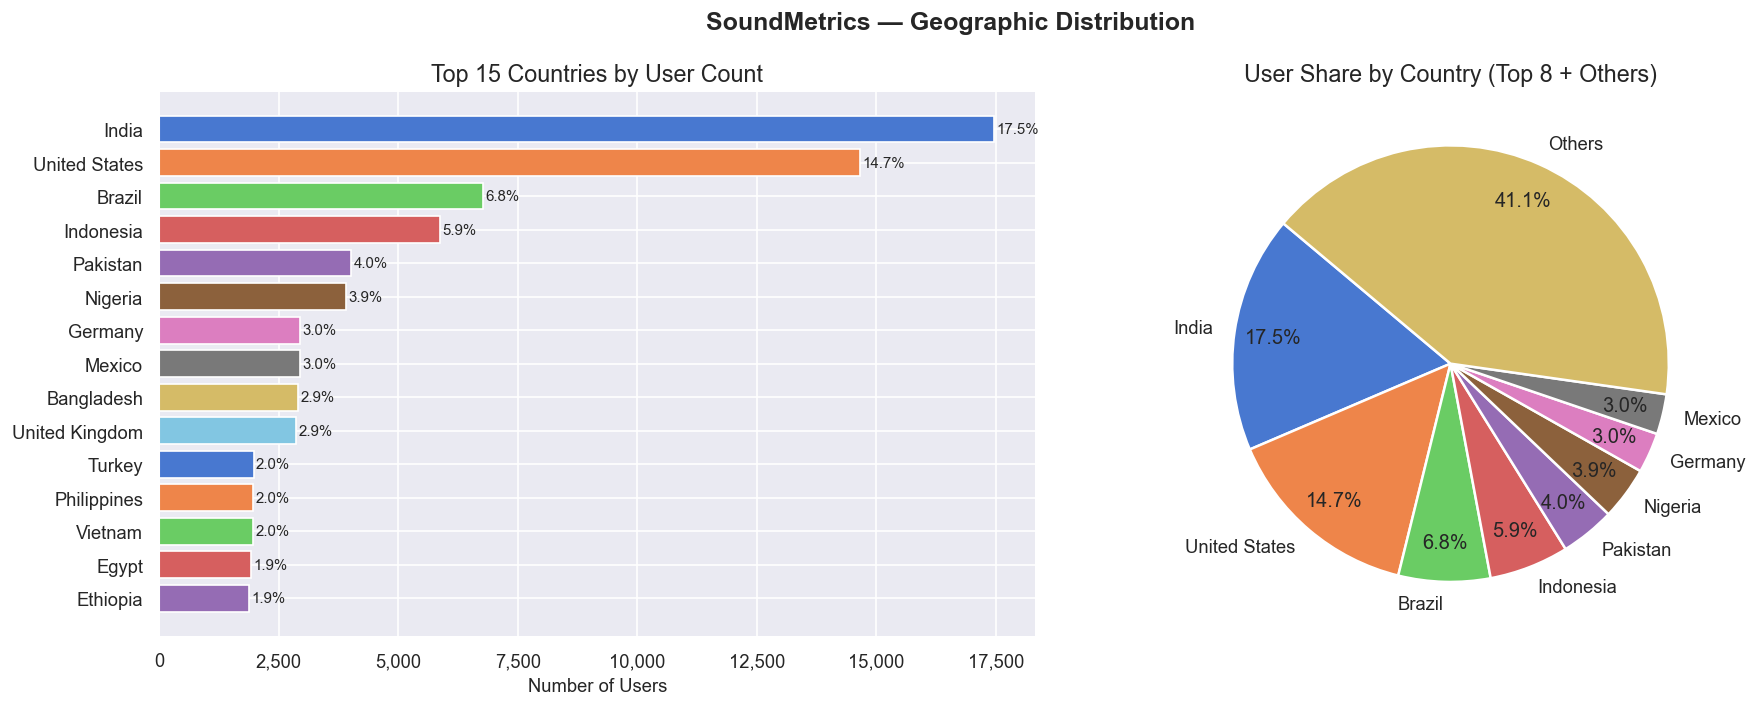


📌 INSIGHT:
   Top country : India (17.5% of users)
   Top 3 countries represent 39.0% of all users


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Horizontal bar — Top 15 countries ────────────
colors = sns.color_palette('muted', len(top_countries))
axes[0].barh(top_countries['country'][::-1], top_countries['users'][::-1],
             color=colors[::-1])
axes[0].set_title('Top 15 Countries by User Count')
axes[0].set_xlabel('Number of Users')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Add value labels on bars
for i, (users_n, pct) in enumerate(zip(top_countries['users'][::-1], top_countries['pct'][::-1])):
    axes[0].text(users_n + 50, i, f'{pct}%', va='center', fontsize=9)

# ── Chart 2: Pie chart — Top 8 + Others ──────────────────
top8    = top_countries.head(8)
others  = pd.DataFrame([{'country': 'Others',
                          'users'  : len(users) - top8['users'].sum()}])
pie_data = pd.concat([top8[['country','users']], others], ignore_index=True)

wedge_props = {'linewidth': 1.5, 'edgecolor': 'white'}
axes[1].pie(pie_data['users'], labels=pie_data['country'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(pie_data)),
            wedgeprops=wedge_props, pctdistance=0.82)
axes[1].set_title('User Share by Country (Top 8 + Others)')

plt.suptitle('SoundMetrics — Geographic Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/02_geographic.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n📌 INSIGHT:')
print(f'   Top country : {top_countries.iloc[0]["country"]} ({top_countries.iloc[0]["pct"]}% of users)')
print(f'   Top 3 countries represent {top_countries.head(3)["pct"].sum():.1f}% of all users')

---
## 3️⃣ Acquisition Channel Analysis

**Business Question:** How are users finding SoundMetrics?

This directly impacts **marketing budget decisions**.
If organic search brings the most users, invest in SEO.
If paid ads bring high-value users, increase ad spend.

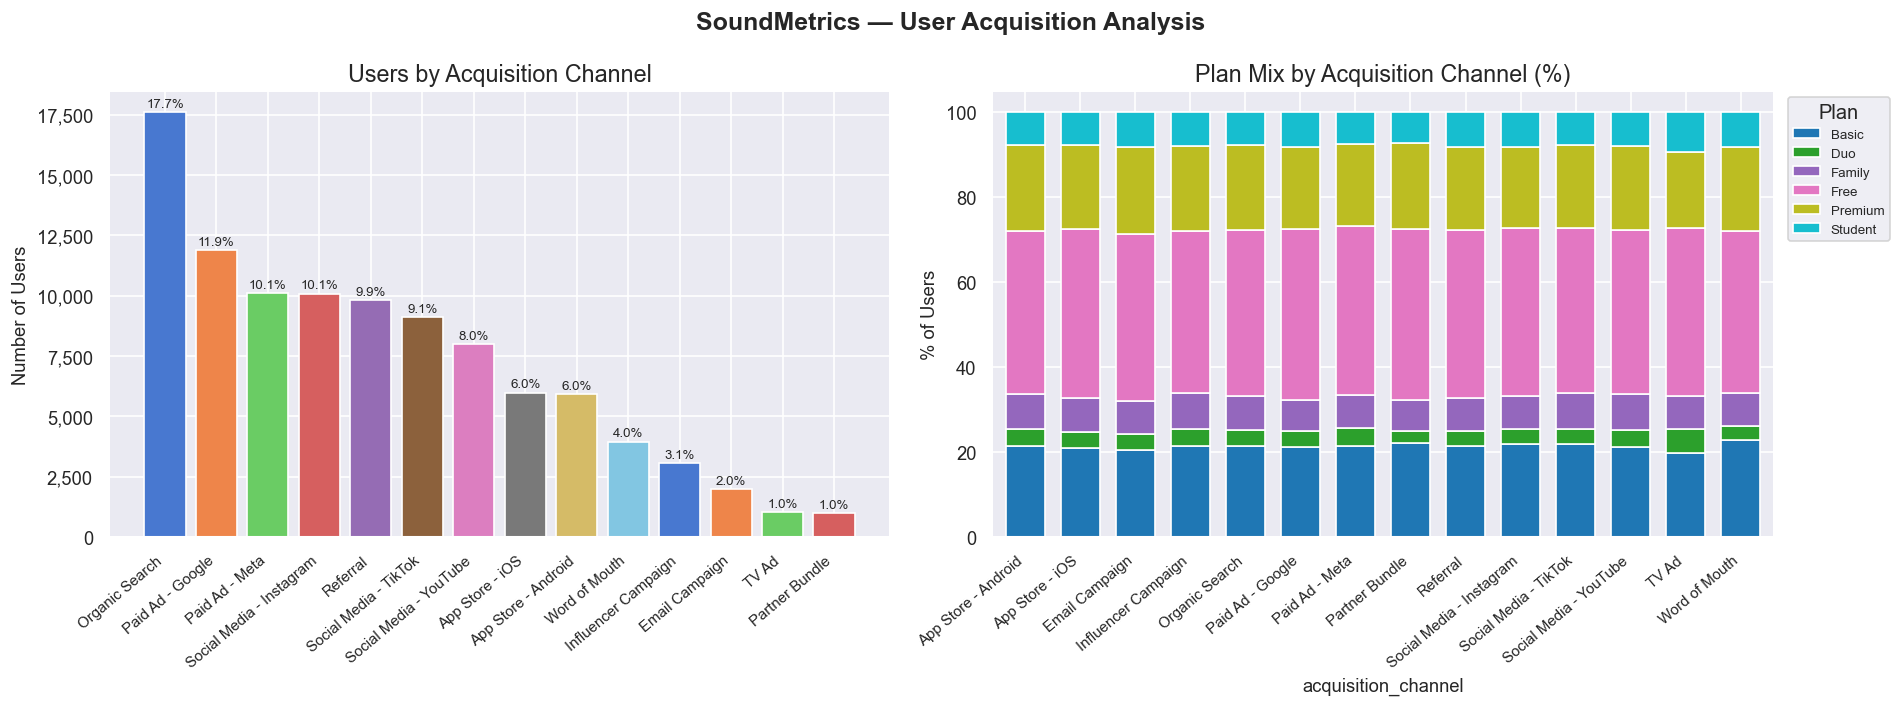


📌 INSIGHT:
   Top acquisition channel: Organic Search (17.7% of users)


In [8]:
channel_counts = (
    users['acquisition_channel']
    .value_counts()
    .reset_index()
)
channel_counts.columns = ['channel', 'users']
channel_counts['pct'] = (channel_counts['users'] / len(users) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Bar chart of channels ───────────────────────
palette = sns.color_palette('muted', len(channel_counts))
bars = axes[0].bar(channel_counts['channel'], channel_counts['users'], color=palette)
axes[0].set_xticklabels(channel_counts['channel'], rotation=40, ha='right', fontsize=9)
axes[0].set_title('Users by Acquisition Channel')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Add percentage labels on top of bars
for bar, pct in zip(bars, channel_counts['pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{pct}%', ha='center', va='bottom', fontsize=8)

# ── Chart 2: Plan type per acquisition channel (stacked) ──
# This shows which channels bring premium vs free users
channel_plan = (
    users.merge(subs[['user_id','plan_type']], on='user_id', how='left')
         .groupby(['acquisition_channel','plan_type'])
         .size()
         .unstack(fill_value=0)
)
# Normalise to percentages
channel_plan_pct = channel_plan.div(channel_plan.sum(axis=1), axis=0) * 100
channel_plan_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       colormap='tab10', width=0.7)
axes[1].set_xticklabels(channel_plan_pct.index, rotation=40, ha='right', fontsize=9)
axes[1].set_title('Plan Mix by Acquisition Channel (%)')
axes[1].set_ylabel('% of Users')
axes[1].legend(title='Plan', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('SoundMetrics — User Acquisition Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/03_acquisition.png', bbox_inches='tight', dpi=150)
plt.show()

top_channel = channel_counts.iloc[0]
print(f'\n📌 INSIGHT:')
print(f'   Top acquisition channel: {top_channel["channel"]} ({top_channel["pct"]}% of users)')

---
## 4️⃣ Subscription Plan Distribution

**Business Question:** What is our free vs paid user ratio?

For SaaS companies, this is called the **freemium conversion rate**.
A healthy music streaming app should aim for at least 25-30% paid users.

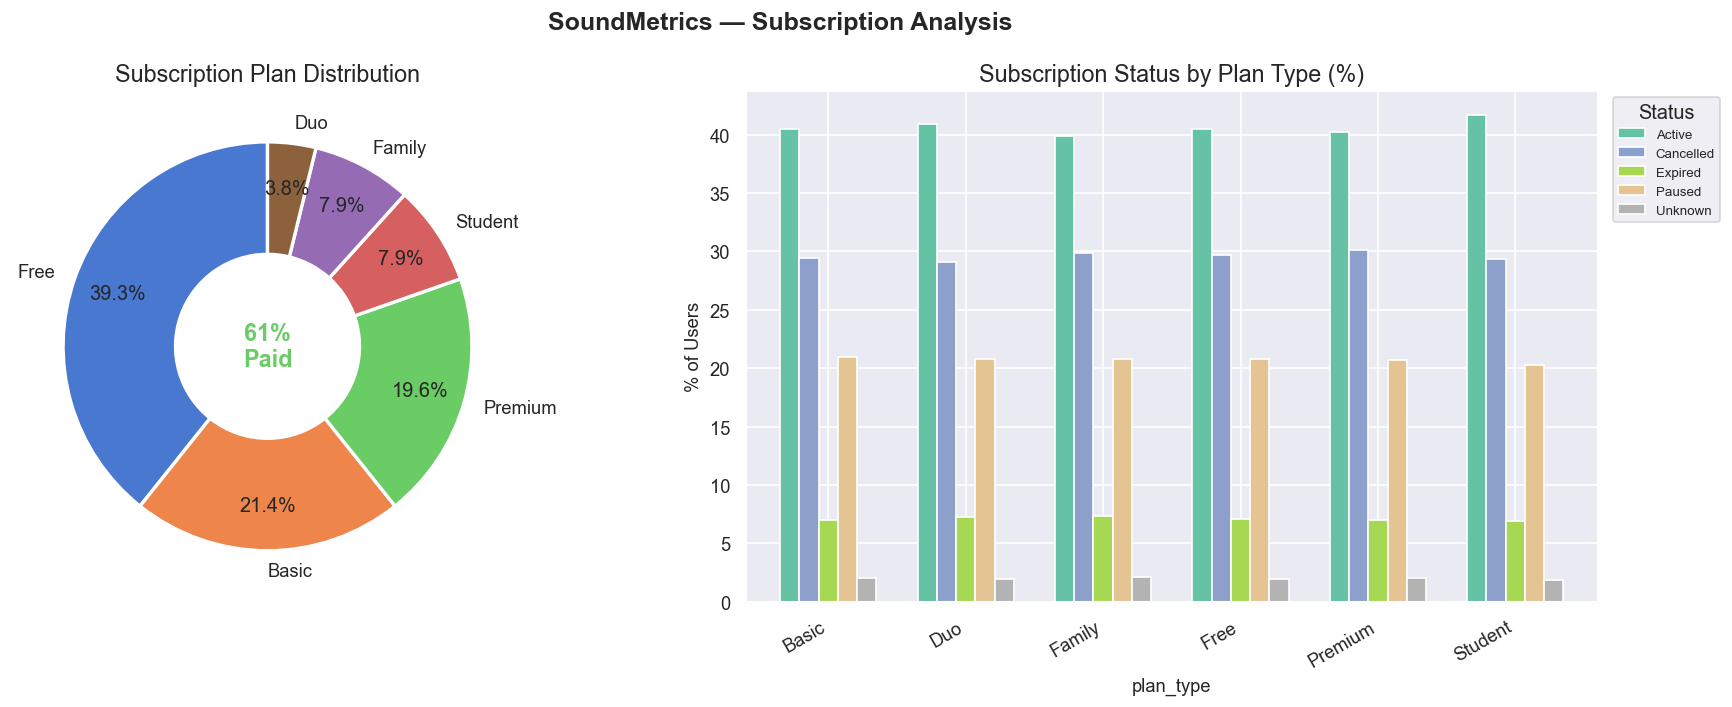


📌 INSIGHT:
   Free users  : 39.3%
   Paid users  : 60.7%
   Top paid plan: Basic


In [9]:
plan_counts = subs['plan_type'].value_counts().reset_index()
plan_counts.columns = ['plan', 'count']
plan_counts['pct'] = (plan_counts['count'] / len(subs) * 100).round(1)

# Separate free vs paid for summary metric
free_pct = plan_counts[plan_counts['plan'] == 'Free']['pct'].values[0]
paid_pct = 100 - free_pct

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Donut chart of plan distribution ─────────────
# A donut chart is a pie chart with a hole in the middle
# Great for showing proportions with a summary metric in the centre
colors = sns.color_palette('muted', len(plan_counts))
wedges, texts, autotexts = axes[0].pie(
    plan_counts['count'],
    labels=plan_counts['plan'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.78
)
# Add paid % in the hole
axes[0].text(0, 0, f'{paid_pct:.0f}%\nPaid',
             ha='center', va='center', fontsize=14, fontweight='bold',
             color=sns.color_palette('muted')[2])
axes[0].set_title('Subscription Plan Distribution')

# ── Chart 2: Plan status breakdown per plan ───────────────
plan_status = (
    subs.groupby(['plan_type', 'status'])
        .size()
        .unstack(fill_value=0)
)
plan_status_pct = plan_status.div(plan_status.sum(axis=1), axis=0) * 100
plan_status_pct.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.7)
axes[1].set_xticklabels(plan_status_pct.index, rotation=30, ha='right')
axes[1].set_title('Subscription Status by Plan Type (%)')
axes[1].set_ylabel('% of Users')
axes[1].legend(title='Status', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

plt.suptitle('SoundMetrics — Subscription Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/04_subscriptions.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n📌 INSIGHT:')
print(f'   Free users  : {free_pct:.1f}%')
print(f'   Paid users  : {paid_pct:.1f}%')
print(f'   Top paid plan: {plan_counts[plan_counts["plan"] != "Free"].iloc[0]["plan"]}')

---
## 5️⃣ Listening Behaviour — When Do Users Listen?

**Business Question:** What time of day do users listen most?

This helps the **infrastructure team** plan server capacity —
scale up during peak hours, scale down at night to save costs.
It also helps the **content team** schedule playlist releases.

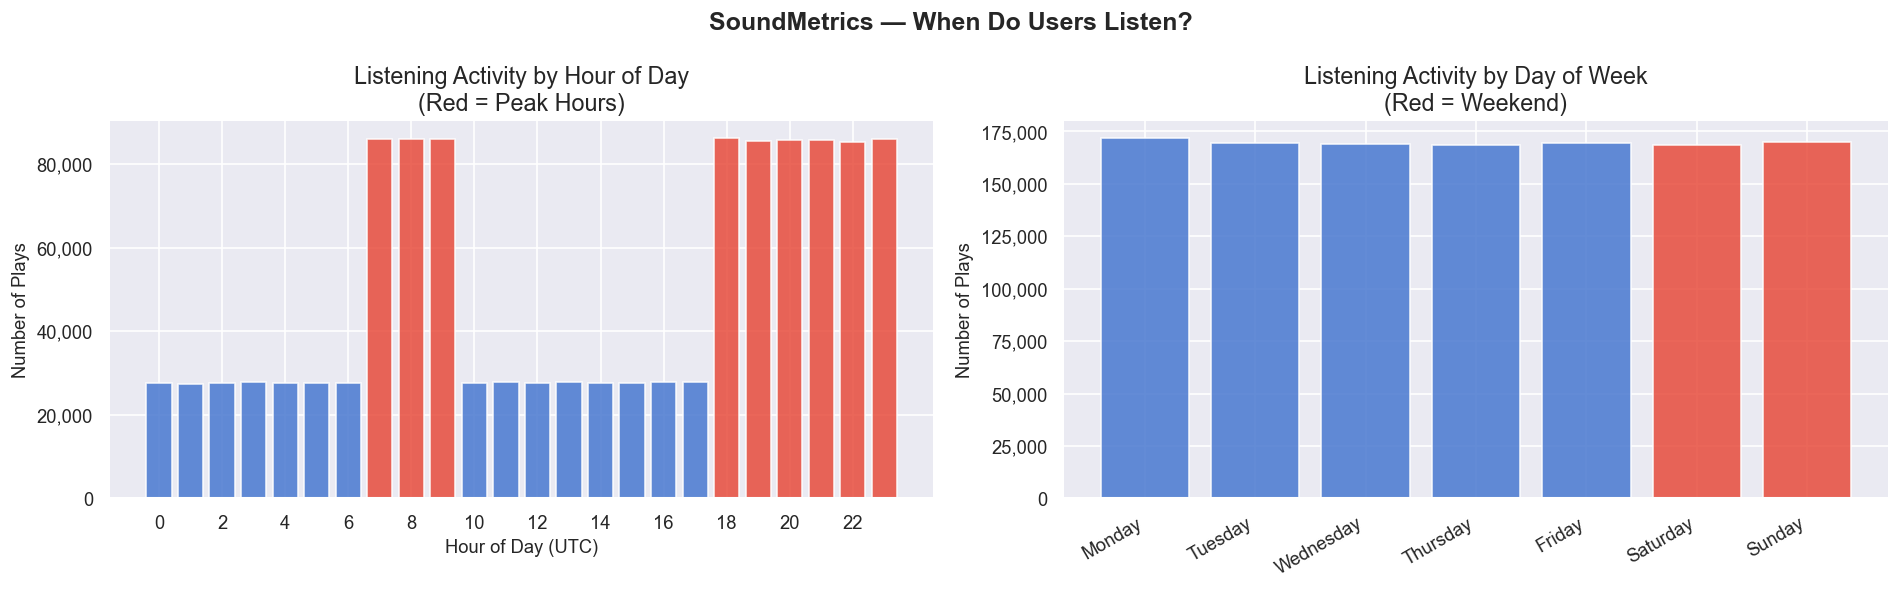


📌 INSIGHT:
   Peak listening hour : 18:00 UTC
   Peak day            : Monday


In [10]:
# Extract hour from event_time string
# event_time looks like '14:32:05' — we split by ':' and take [0]
events['hour'] = events['event_time'].str.split(':').str[0].astype(int)
events['month'] = events['event_date'].dt.month
events['day_of_week'] = events['event_date'].dt.day_name()

# Count events per hour
hourly = events.groupby('hour').size().reset_index(name='plays')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Listening by hour of day ─────────────────────
# Colour peak hours differently to highlight them
bar_colors = ['#e74c3c' if h in range(18,24) or h in range(7,10)
               else sns.color_palette('muted')[0]
               for h in hourly['hour']]
axes[0].bar(hourly['hour'], hourly['plays'], color=bar_colors, alpha=0.85, width=0.8)
axes[0].set_title('Listening Activity by Hour of Day\n(Red = Peak Hours)')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Number of Plays')
axes[0].set_xticks(range(0, 24, 2))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Chart 2: Listening by day of week ─────────────────────
day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily      = events.groupby('day_of_week').size().reindex(day_order).reset_index()
daily.columns = ['day', 'plays']

weekend_colors = ['#e74c3c' if d in ['Saturday','Sunday']
                   else sns.color_palette('muted')[0] for d in daily['day']]
axes[1].bar(daily['day'], daily['plays'], color=weekend_colors, alpha=0.85)
axes[1].set_xticklabels(daily['day'], rotation=30, ha='right')
axes[1].set_title('Listening Activity by Day of Week\n(Red = Weekend)')
axes[1].set_ylabel('Number of Plays')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('SoundMetrics — When Do Users Listen?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/05_listening_time.png', bbox_inches='tight', dpi=150)
plt.show()

peak_hour = hourly.loc[hourly['plays'].idxmax(), 'hour']
print(f'\n📌 INSIGHT:')
print(f'   Peak listening hour : {peak_hour}:00 UTC')
print(f'   Peak day            : {daily.loc[daily["plays"].idxmax(), "day"]}')

---
## 6️⃣ Genre Popularity Analysis

**Business Question:** What genres do our users love most?

This is critical for **music licensing negotiations**.
If 30% of plays are Hip-Hop, SoundMetrics needs strong Hip-Hop label deals.
We also check skip rates per genre — a high skip rate means users
don't actually enjoy that content despite clicking on it.

In [11]:
# Total plays per genre
genre_plays = (
    events[events['genre'] != 'Unknown']
    .groupby('genre')
    .agg(
        total_plays    = ('event_id', 'count'),
        skips          = ('is_skip', 'sum'),
        avg_duration   = ('listen_duration_sec', 'mean')
    )
    .reset_index()
)
genre_plays['skip_rate_pct'] = (genre_plays['skips'] / genre_plays['total_plays'] * 100).round(1)
genre_plays['avg_duration']  = genre_plays['avg_duration'].round(0).astype(int)
genre_plays = genre_plays.sort_values('total_plays', ascending=False)

print(genre_plays[['genre','total_plays','skip_rate_pct','avg_duration']].to_string(index=False))

                 genre  total_plays  skip_rate_pct  avg_duration
                 Indie        50933          18.00           153
                   Pop        50922          17.70           154
            Arabic Pop        50827          17.80           154
             Anime OST        50761          18.10           153
                  Rock        50758          18.00           153
            R&B / Soul        50748          18.20           153
               Country        50740          17.70           154
      Electronic / EDM        50730          18.00           153
             Afrobeats        50717          18.00           153
      Gospel / Worship        50711          18.10           154
              Podcasts        50688          18.00           153
             Classical        50595          18.20           153
                 K-Pop        50509          18.00           153
           Turkish Pop        50503          17.70           154
Devotional / Spiritual   

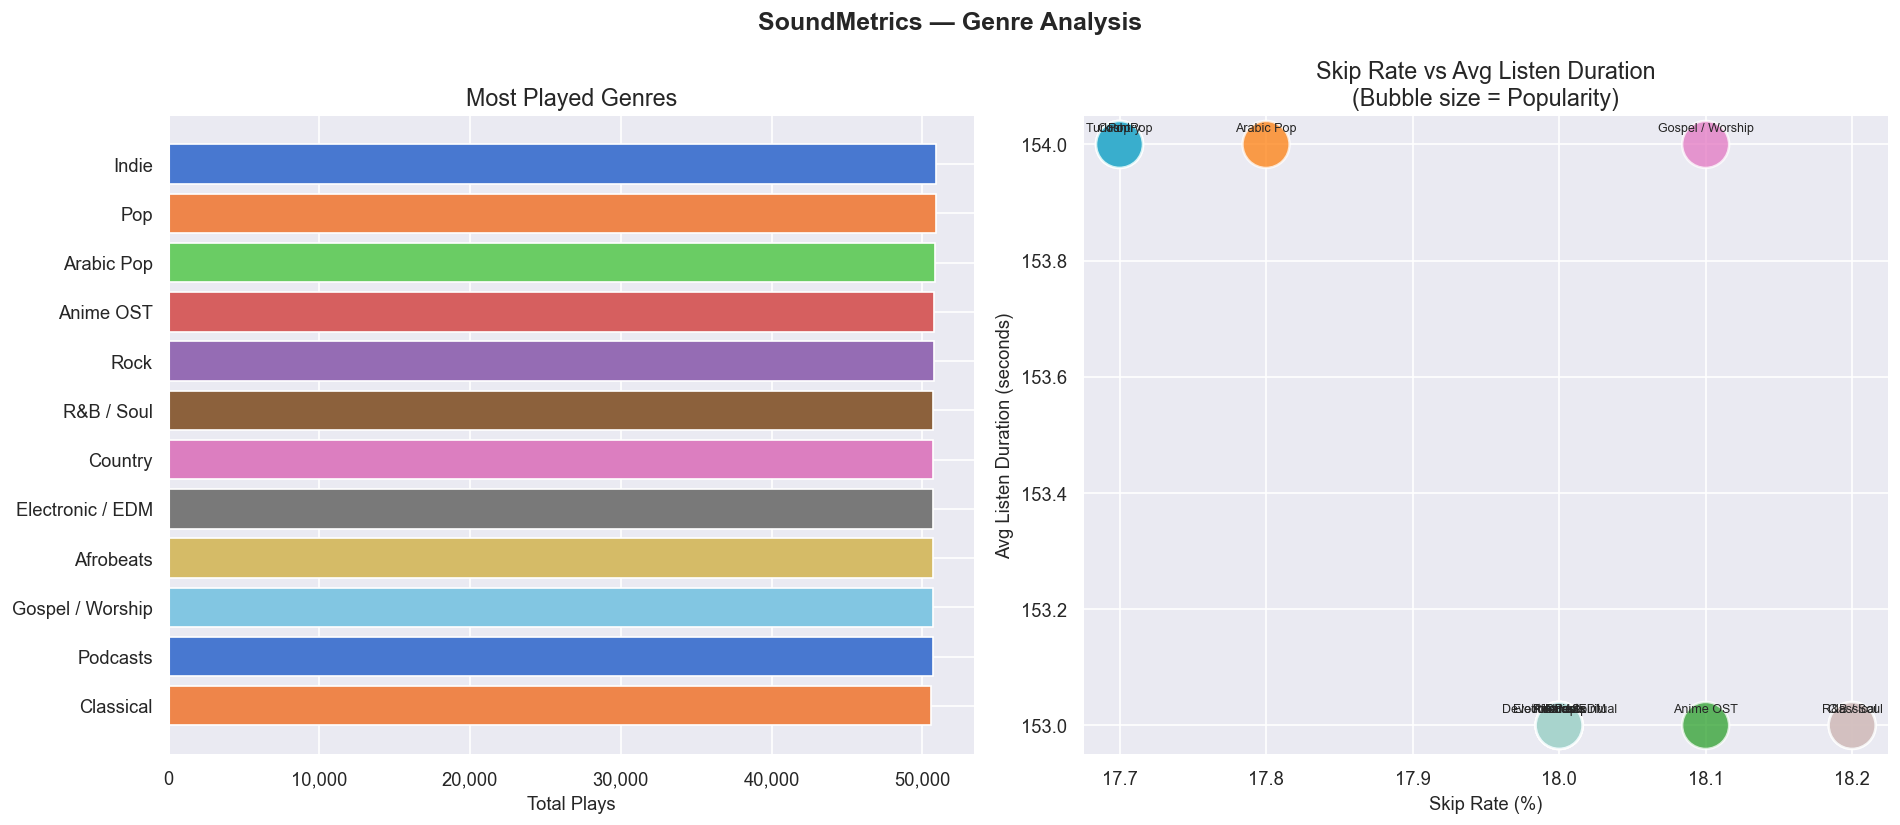


📌 INSIGHTS:
   Most played genre       : Indie (50,933 plays)
   Lowest skip rate genre  : Pop (17.7% skipped)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart 1: Top genres by play count ─────────────────────
top_genres = genre_plays.head(12)
palette    = sns.color_palette('muted', len(top_genres))
axes[0].barh(top_genres['genre'][::-1], top_genres['total_plays'][::-1], color=palette[::-1])
axes[0].set_title('Most Played Genres')
axes[0].set_xlabel('Total Plays')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Chart 2: Skip rate per genre (bubble chart) ───────────
# Bubble size = total plays, position = skip rate vs avg duration
scatter_data = genre_plays.head(15)
bubble_sizes  = (scatter_data['total_plays'] / scatter_data['total_plays'].max() * 800)
scatter = axes[1].scatter(
    scatter_data['skip_rate_pct'],
    scatter_data['avg_duration'],
    s=bubble_sizes,
    c=range(len(scatter_data)),
    cmap='tab20',
    alpha=0.75,
    edgecolors='white',
    linewidth=1.5
)
# Label each bubble with genre name
for _, row in scatter_data.iterrows():
    axes[1].annotate(row['genre'],
                     (row['skip_rate_pct'], row['avg_duration']),
                     fontsize=7.5, ha='center', va='bottom',
                     xytext=(0, 6), textcoords='offset points')
axes[1].set_title('Skip Rate vs Avg Listen Duration\n(Bubble size = Popularity)')
axes[1].set_xlabel('Skip Rate (%)')
axes[1].set_ylabel('Avg Listen Duration (seconds)')

plt.suptitle('SoundMetrics — Genre Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/06_genres.png', bbox_inches='tight', dpi=150)
plt.show()

top_genre     = genre_plays.iloc[0]
lowest_skip   = genre_plays.nsmallest(1, 'skip_rate_pct').iloc[0]
print(f'\n📌 INSIGHTS:')
print(f'   Most played genre       : {top_genre["genre"]} ({top_genre["total_plays"]:,} plays)')
print(f'   Lowest skip rate genre  : {lowest_skip["genre"]} ({lowest_skip["skip_rate_pct"]}% skipped)')

---
## 7️⃣ Device Usage Analysis

**Business Question:** What devices do users listen on?

This tells the **product & engineering team** where to focus.
If 60% of plays are on Mobile, mobile app quality is the top priority.

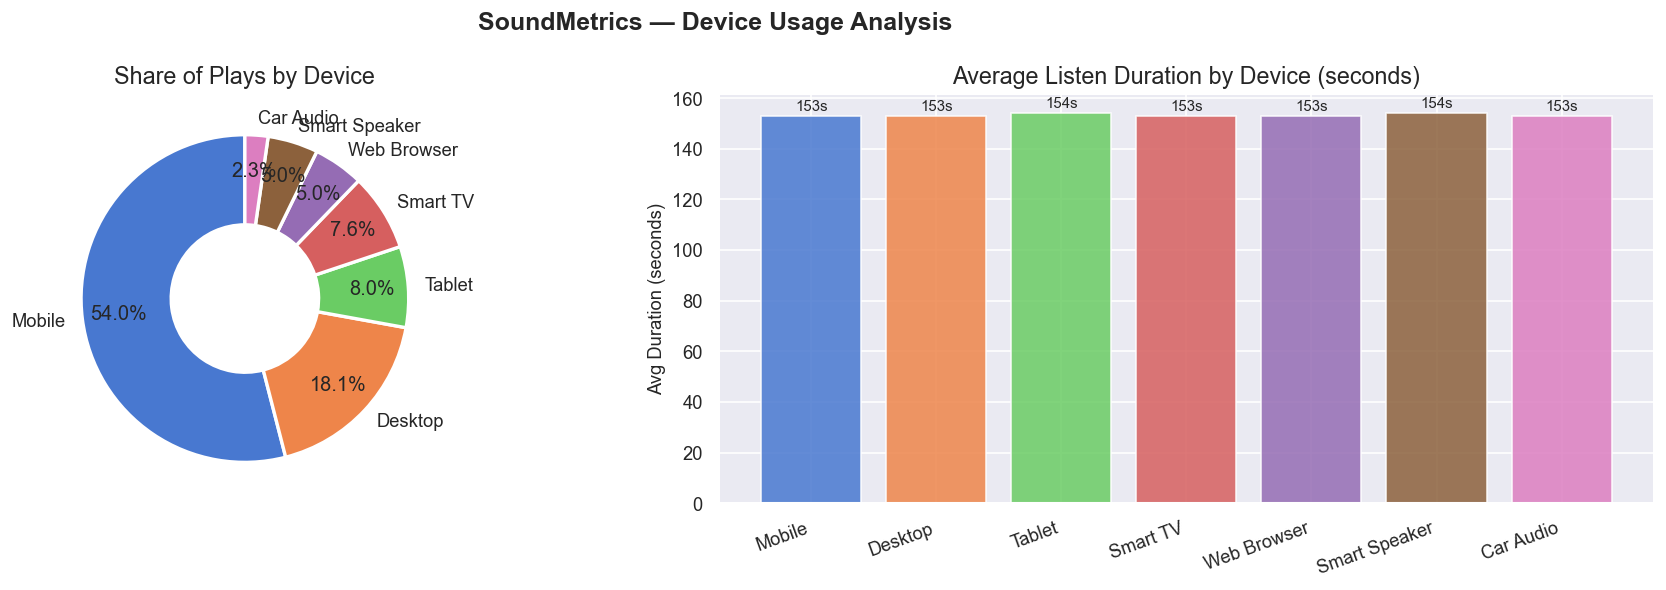


📌 INSIGHT:
   Top device: Mobile (54.0% of plays)
   Longest sessions on: Tablet


In [13]:
device_plays = (
    events[events['device'] != 'Unknown']
    .groupby('device')
    .agg(plays=('event_id','count'), avg_duration=('listen_duration_sec','mean'))
    .reset_index()
    .sort_values('plays', ascending=False)
)
device_plays['pct'] = (device_plays['plays'] / device_plays['plays'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Device share donut ───────────────────────────
colors = sns.color_palette('muted', len(device_plays))
axes[0].pie(device_plays['plays'], labels=device_plays['device'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'width':0.55,'edgecolor':'white','linewidth':2},
            pctdistance=0.78)
axes[0].set_title('Share of Plays by Device')

# ── Chart 2: Avg listen duration per device ───────────────
# Smart TVs and speakers tend to have longer listen durations
bar_colors = sns.color_palette('muted', len(device_plays))
axes[1].bar(device_plays['device'], device_plays['avg_duration'].round(0),
            color=bar_colors, alpha=0.85)
axes[1].set_title('Average Listen Duration by Device (seconds)')
axes[1].set_ylabel('Avg Duration (seconds)')
axes[1].set_xticklabels(device_plays['device'], rotation=20, ha='right')
# Add value labels
for bar, val in zip(axes[1].patches, device_plays['avg_duration']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.0f}s', ha='center', va='bottom', fontsize=9)

plt.suptitle('SoundMetrics — Device Usage Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/07_devices.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n📌 INSIGHT:')
print(f'   Top device: {device_plays.iloc[0]["device"]} ({device_plays.iloc[0]["pct"]}% of plays)')
print(f'   Longest sessions on: {device_plays.nlargest(1,"avg_duration").iloc[0]["device"]}')

---
## 8️⃣ Seasonal Listening Trends

**Business Question:** Does listening activity vary by month?

We expect peaks in December (holidays) and July (summer).
This helps plan **content releases and server scaling**.

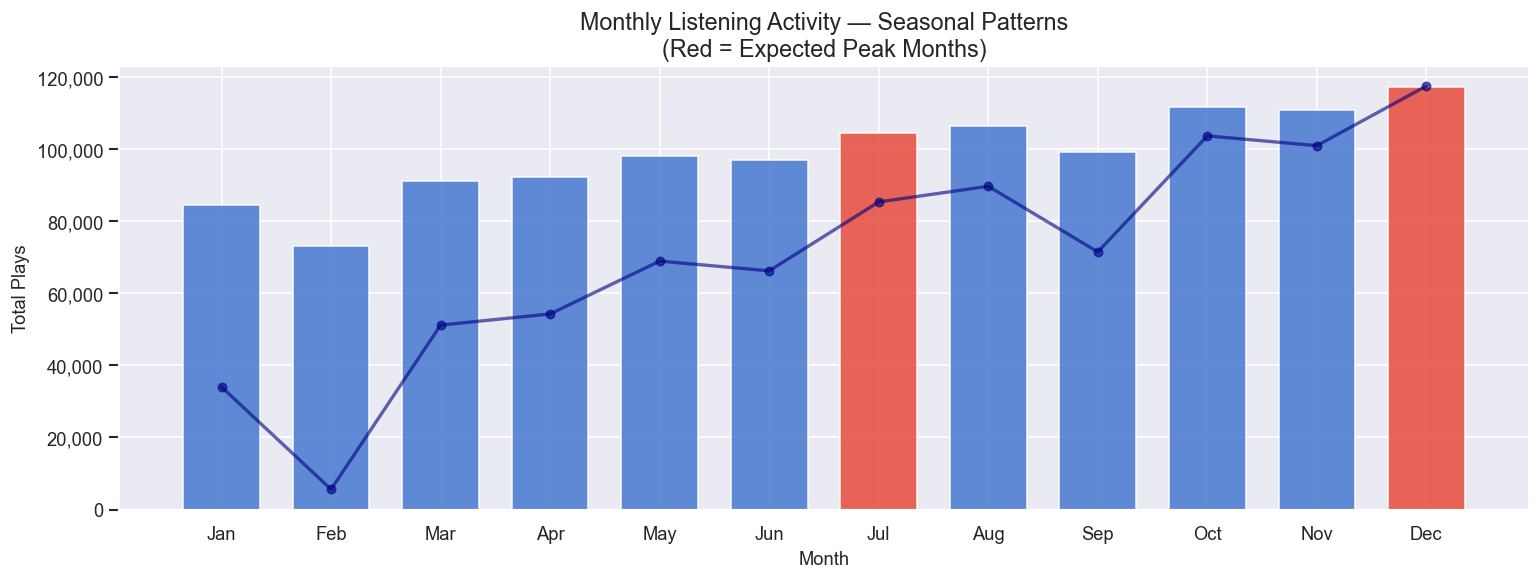


📌 INSIGHT:
   Peak month  : Dec (117,333 plays)
   Quietest    : Feb


In [14]:
month_plays = (
    events.groupby('month')
          .size()
          .reset_index(name='plays')
)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_plays['month_name'] = month_plays['month'].map(month_names)

fig, ax = plt.subplots(figsize=(13, 5))

# Highlight peak months in a different colour
peak_months = [7, 12]
bar_colors  = ['#e74c3c' if m in peak_months
                else sns.color_palette('muted')[0]
                for m in month_plays['month']]

bars = ax.bar(month_plays['month_name'], month_plays['plays'],
               color=bar_colors, alpha=0.85, width=0.7)

# Add a trend line on top
ax2 = ax.twinx()   # second y-axis for the line
ax2.plot(month_plays['month_name'], month_plays['plays'],
          color='navy', linewidth=2, marker='o', markersize=5, alpha=0.6)
ax2.set_yticks([])

ax.set_title('Monthly Listening Activity — Seasonal Patterns\n(Red = Expected Peak Months)',
              fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Total Plays')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('data/charts/08_seasonal.png', bbox_inches='tight', dpi=150)
plt.show()

peak_m = month_plays.loc[month_plays['plays'].idxmax()]
print(f'\n📌 INSIGHT:')
print(f'   Peak month  : {peak_m["month_name"]} ({peak_m["plays"]:,} plays)')
print(f'   Quietest    : {month_plays.loc[month_plays["plays"].idxmin(), "month_name"]}')

---
## 9️⃣ Revenue Trend Analysis

**Business Question:** How has revenue grown over time?

We look at **Monthly Revenue** and **payment success rates**.
This is what the finance team tracks every single month.

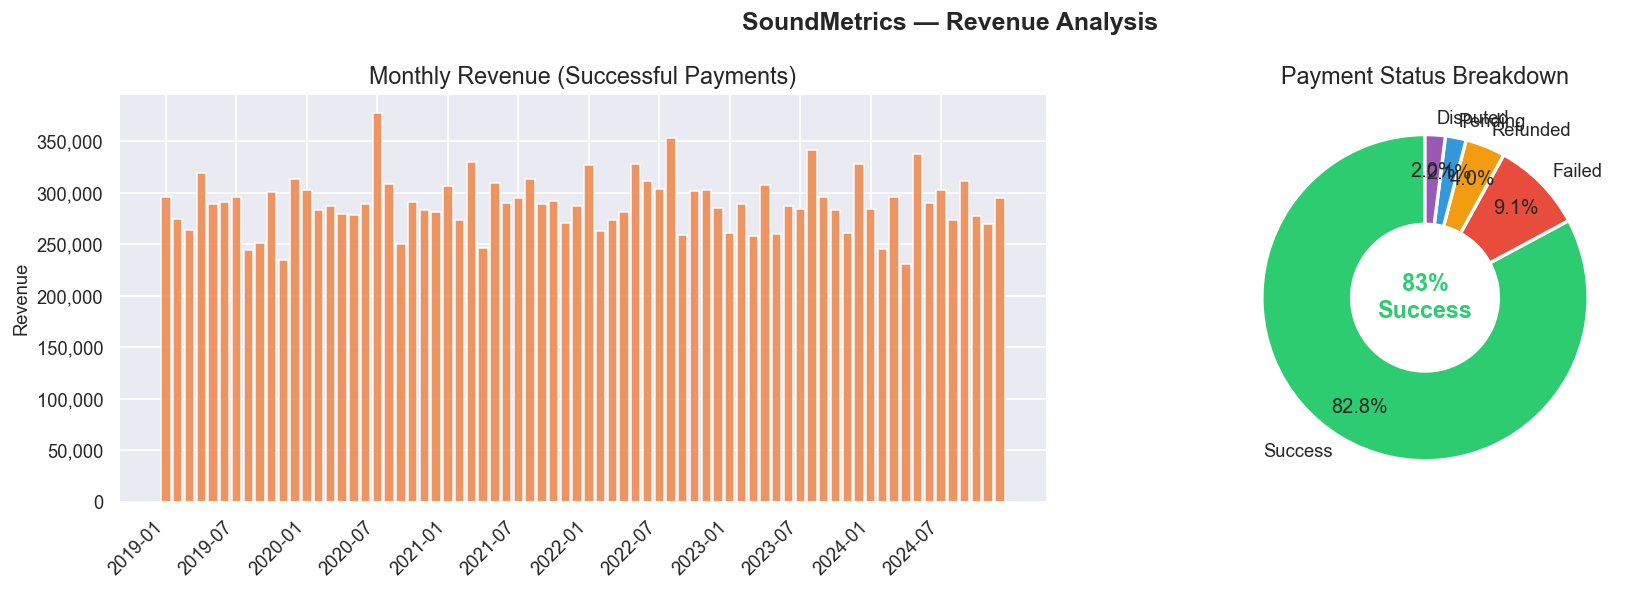


📌 INSIGHTS:
   Total revenue (all time)  :   20,829,131
   Payment success rate      : 82.8%
   Failed payment rate       : 9.1% (revenue at risk)


In [15]:
# Monthly revenue from successful payments only
pays['payment_month'] = pays['payment_date'].dt.to_period('M')
monthly_rev = (
    pays[pays['status'] == 'Success']
    .groupby('payment_month')
    .agg(revenue=('amount','sum'), transactions=('payment_id','count'))
    .reset_index()
)
monthly_rev['payment_month'] = monthly_rev['payment_month'].astype(str)
monthly_rev['cumulative_rev'] = monthly_rev['revenue'].cumsum()

# Payment status breakdown
pay_status = pays['status'].value_counts().reset_index()
pay_status.columns = ['status','count']
pay_status['pct'] = (pay_status['count'] / len(pays) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Monthly revenue bar ─────────────────────────
x_pos    = range(len(monthly_rev))
x_ticks  = list(range(0, len(monthly_rev), 6))
x_labels = [monthly_rev['payment_month'].iloc[i] for i in x_ticks]

axes[0].bar(x_pos, monthly_rev['revenue'],
             color=sns.color_palette('muted')[1], alpha=0.85)
axes[0].set_xticks(x_ticks)
axes[0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0].set_title('Monthly Revenue (Successful Payments)')
axes[0].set_ylabel('Revenue')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Chart 2: Payment status donut ────────────────────────
colors = ['#2ecc71','#e74c3c','#f39c12','#3498db','#9b59b6']
axes[1].pie(pay_status['count'], labels=pay_status['status'],
             autopct='%1.1f%%', colors=colors[:len(pay_status)],
             startangle=90,
             wedgeprops={'width':0.55,'edgecolor':'white','linewidth':2},
             pctdistance=0.78)
success_pct = pay_status[pay_status['status']=='Success']['pct'].values[0]
axes[1].text(0, 0, f'{success_pct:.0f}%\nSuccess',
              ha='center', va='center', fontsize=14, fontweight='bold', color='#2ecc71')
axes[1].set_title('Payment Status Breakdown')

plt.suptitle('SoundMetrics — Revenue Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/09_revenue.png', bbox_inches='tight', dpi=150)
plt.show()

total_rev = monthly_rev['revenue'].sum()
print(f'\n📌 INSIGHTS:')
print(f'   Total revenue (all time)  : {total_rev:>12,.0f}')
print(f'   Payment success rate      : {success_pct:.1f}%')
failed_pct = pay_status[pay_status['status']=='Failed']['pct'].values
if len(failed_pct):
    print(f'   Failed payment rate       : {failed_pct[0]:.1f}% (revenue at risk)')

---
## 🔟 Support Ticket Analysis

**Business Question:** What are users complaining about most?

This tells the **product and customer success teams** where to focus.
We also look at CSAT (Customer Satisfaction) scores by segment.

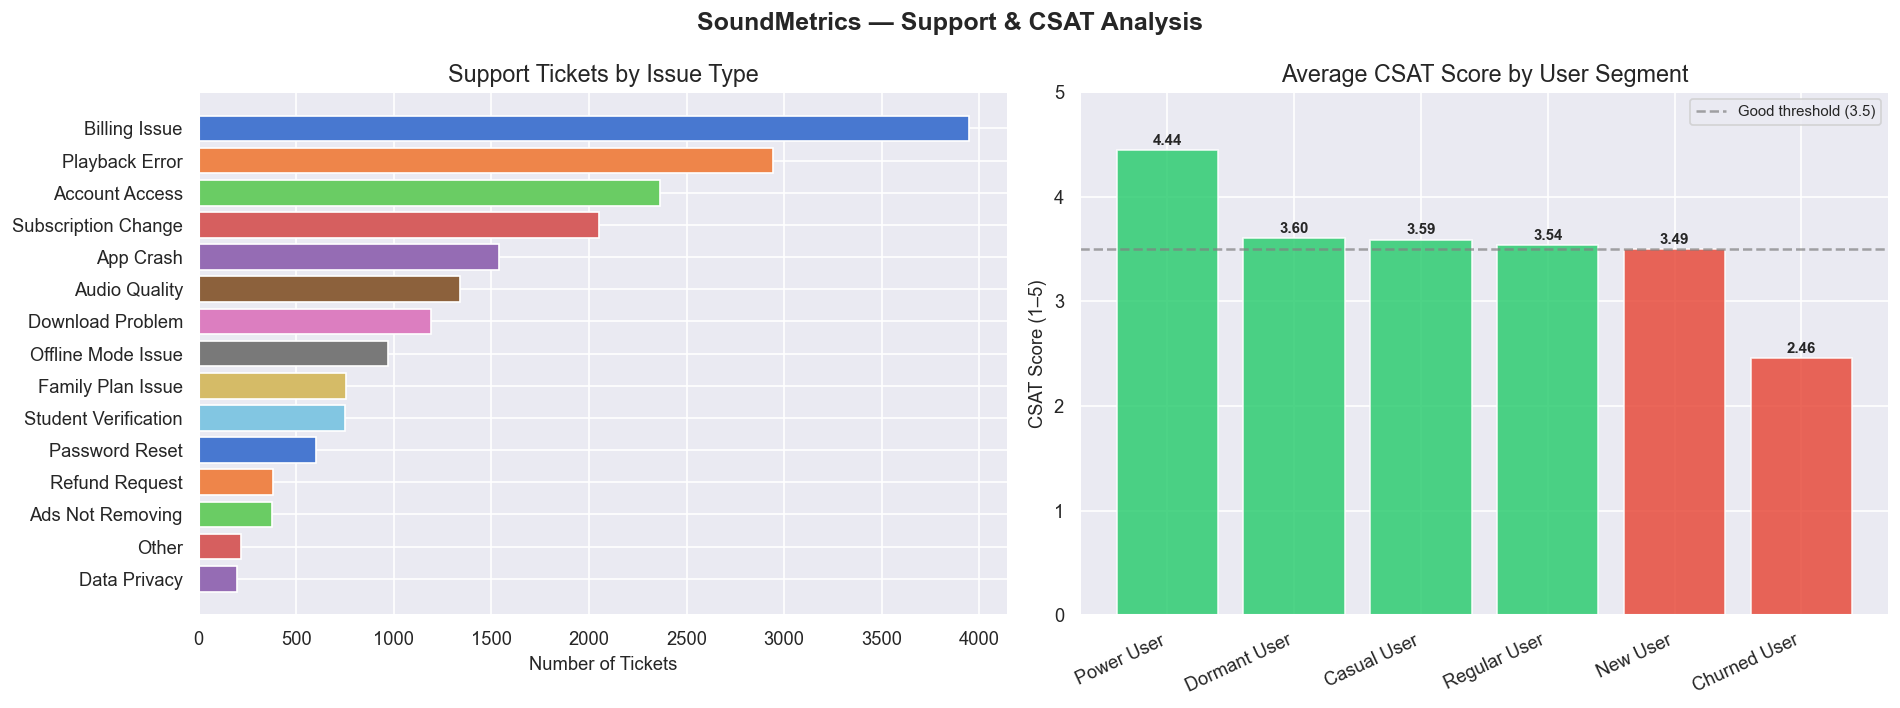


📌 INSIGHTS:
   Top issue type          : Billing Issue
   Best CSAT segment       : Power User (4.44/5)
   Worst CSAT segment      : Churned User (2.46/5)


In [16]:
issue_counts = (
    tickets[tickets['issue_type'] != 'Unknown']
    .groupby('issue_type')
    .agg(
        count          = ('ticket_id', 'count'),
        avg_resolution = ('resolution_days', 'mean'),
        avg_csat       = ('satisfaction_score', 'mean')
    )
    .reset_index()
    .sort_values('count', ascending=False)
)
issue_counts['avg_resolution'] = issue_counts['avg_resolution'].round(1)
issue_counts['avg_csat']       = issue_counts['avg_csat'].round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Issue type frequency ────────────────────────
palette = sns.color_palette('muted', len(issue_counts))
axes[0].barh(issue_counts['issue_type'][::-1], issue_counts['count'][::-1],
              color=palette[::-1])
axes[0].set_title('Support Tickets by Issue Type')
axes[0].set_xlabel('Number of Tickets')

# ── Chart 2: CSAT score by user segment ──────────────────
# Merge tickets with user segment
ticket_seg = tickets.merge(users[['user_id','user_segment']], on='user_id', how='left')
csat_by_seg = (
    ticket_seg[ticket_seg['satisfaction_score'].notna()]
    .groupby('user_segment')['satisfaction_score']
    .mean()
    .reset_index()
    .sort_values('satisfaction_score', ascending=False)
)

bar_colors = ['#2ecc71' if s >= 3.5 else '#e74c3c'
               for s in csat_by_seg['satisfaction_score']]
bars = axes[1].bar(csat_by_seg['user_segment'], csat_by_seg['satisfaction_score'],
                    color=bar_colors, alpha=0.85)
axes[1].axhline(y=3.5, color='grey', linestyle='--', alpha=0.7, label='Good threshold (3.5)')
axes[1].set_xticklabels(csat_by_seg['user_segment'], rotation=25, ha='right')
axes[1].set_title('Average CSAT Score by User Segment')
axes[1].set_ylabel('CSAT Score (1–5)')
axes[1].set_ylim(0, 5)
axes[1].legend(fontsize=9)
for bar, val in zip(bars, csat_by_seg['satisfaction_score']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.05,
                  f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('SoundMetrics — Support & CSAT Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/10_support.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n📌 INSIGHTS:')
print(f'   Top issue type          : {issue_counts.iloc[0]["issue_type"]}')
print(f'   Best CSAT segment       : {csat_by_seg.iloc[0]["user_segment"]} ({csat_by_seg.iloc[0]["satisfaction_score"]:.2f}/5)')
print(f'   Worst CSAT segment      : {csat_by_seg.iloc[-1]["user_segment"]} ({csat_by_seg.iloc[-1]["satisfaction_score"]:.2f}/5)')

---
## 1️⃣1️⃣ User Segment Comparison

**Business Question:** How do our 6 user segments behave differently?

This is the **foundation for Phase 5 — Customer Segmentation**.
We compare segments on listening activity, plan type, and payment behaviour.

In [17]:
# Listening events per segment
events_seg = events.merge(users[['user_id','user_segment']], on='user_id', how='left')
seg_listening = (
    events_seg.groupby('user_segment')
               .agg(
                   total_plays  = ('event_id', 'count'),
                   avg_duration = ('listen_duration_sec', 'mean'),
                   skip_rate    = ('is_skip', 'mean')
               )
               .reset_index()
)
seg_listening['skip_rate'] = (seg_listening['skip_rate'] * 100).round(1)
seg_listening['avg_duration'] = seg_listening['avg_duration'].round(0)

# Segment sizes from users table
seg_sizes = users['user_segment'].value_counts().reset_index()
seg_sizes.columns = ['user_segment', 'user_count']
seg_listening = seg_listening.merge(seg_sizes, on='user_segment')
seg_listening['plays_per_user'] = (seg_listening['total_plays'] / seg_listening['user_count']).round(1)

print(seg_listening[['user_segment','user_count','plays_per_user','avg_duration','skip_rate']].to_string(index=False))

user_segment  user_count  plays_per_user  avg_duration  skip_rate
 Casual User       24955            6.20        153.00      18.00
Churned User        9841            0.10        156.00      17.00
Dormant User       14891            0.80        152.00      18.80
    New User        4975            9.10        153.00      18.10
  Power User       15037           34.20        153.00      18.00
Regular User       29801           15.20        153.00      18.00


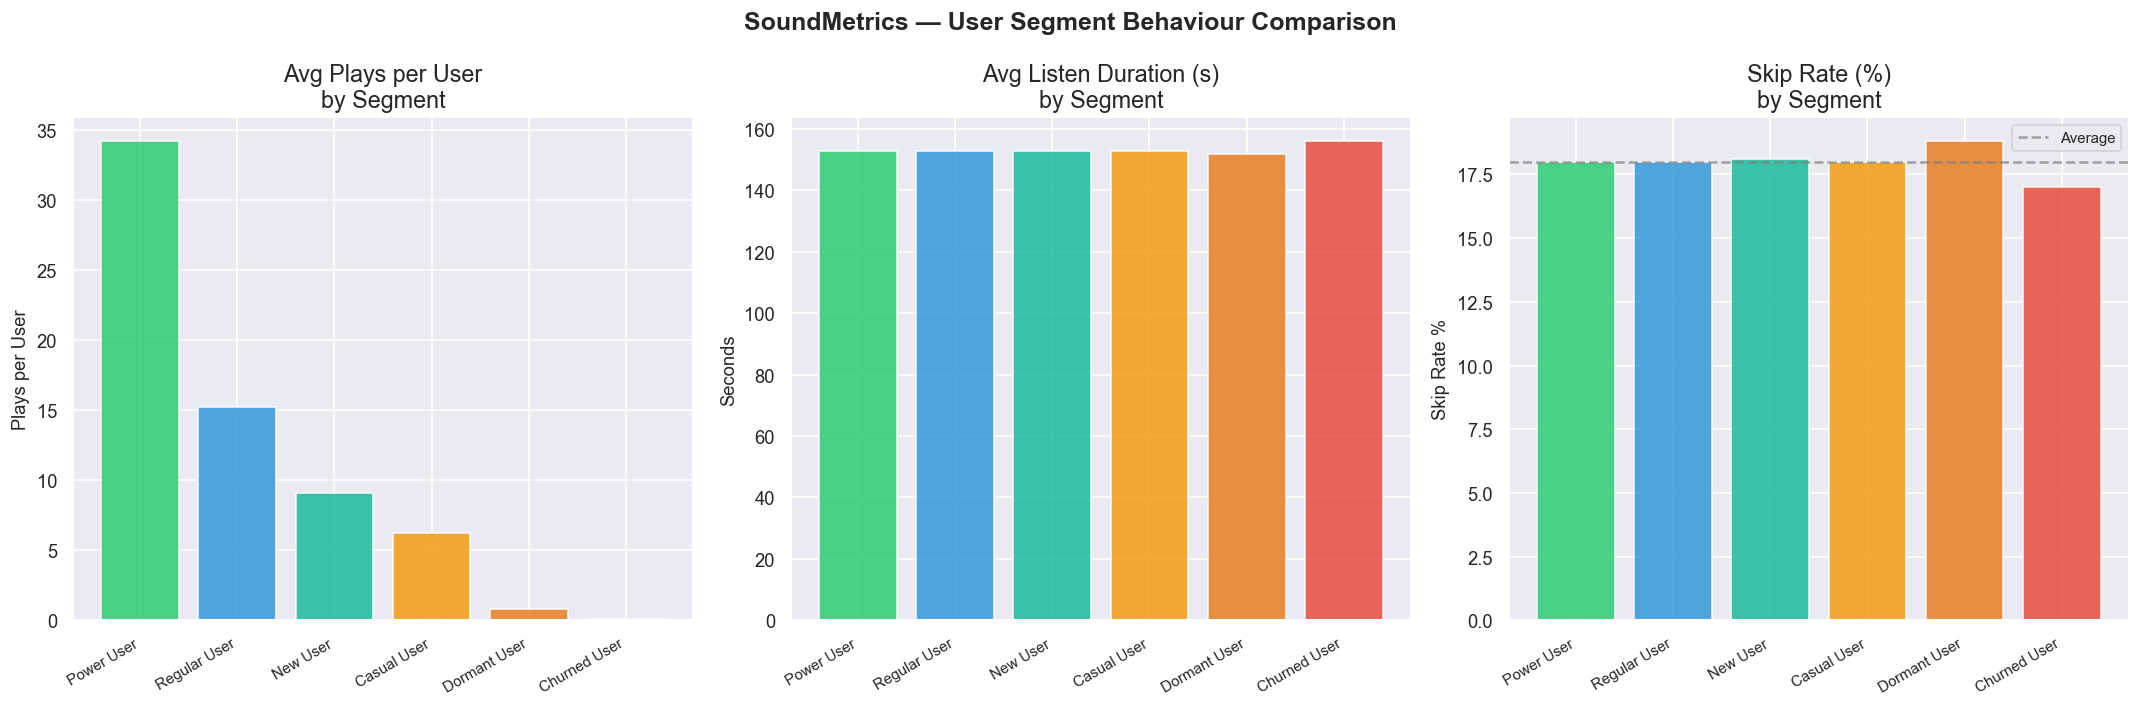


📌 INSIGHT:
   Power Users listen the most and skip the least — highest engagement
   Churned Users have zero plays — they are gone
   Dormant Users still have accounts — recovery opportunity!


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

seg_order = ['Power User','Regular User','New User','Casual User','Dormant User','Churned User']
seg_listening = seg_listening.set_index('user_segment').reindex(seg_order).reset_index()
seg_colors    = ['#2ecc71','#3498db','#1abc9c','#f39c12','#e67e22','#e74c3c']

# ── Chart 1: Plays per user ───────────────────────────────
axes[0].bar(seg_listening['user_segment'], seg_listening['plays_per_user'],
             color=seg_colors, alpha=0.85)
axes[0].set_xticklabels(seg_listening['user_segment'], rotation=30, ha='right', fontsize=9)
axes[0].set_title('Avg Plays per User\nby Segment')
axes[0].set_ylabel('Plays per User')

# ── Chart 2: Avg listen duration ─────────────────────────
axes[1].bar(seg_listening['user_segment'], seg_listening['avg_duration'],
             color=seg_colors, alpha=0.85)
axes[1].set_xticklabels(seg_listening['user_segment'], rotation=30, ha='right', fontsize=9)
axes[1].set_title('Avg Listen Duration (s)\nby Segment')
axes[1].set_ylabel('Seconds')

# ── Chart 3: Skip rate ────────────────────────────────────
axes[2].bar(seg_listening['user_segment'], seg_listening['skip_rate'],
             color=seg_colors, alpha=0.85)
axes[2].set_xticklabels(seg_listening['user_segment'], rotation=30, ha='right', fontsize=9)
axes[2].set_title('Skip Rate (%)\nby Segment')
axes[2].set_ylabel('Skip Rate %')
axes[2].axhline(y=seg_listening['skip_rate'].mean(), color='grey',
                 linestyle='--', alpha=0.7, label='Average')
axes[2].legend(fontsize=9)

plt.suptitle('SoundMetrics — User Segment Behaviour Comparison',
              fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/charts/11_segments.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📌 INSIGHT:')
print('   Power Users listen the most and skip the least — highest engagement')
print('   Churned Users have zero plays — they are gone')
print('   Dormant Users still have accounts — recovery opportunity!')

---
## 📋 EDA Summary — Key Findings

Always end an EDA notebook with a clean written summary.
This is what you would present to a product manager or CEO.

In [19]:
print('=' * 60)
print('  SOUNDMETRICS — EDA KEY FINDINGS')
print('=' * 60)

findings = [
    ('User Base',    f'{len(users):,} active users across {users["country"].nunique()} countries'),
    ('Growth',       'Consistent user growth from 2019 to 2024'),
    ('Top Market',   f'{users["country"].value_counts().index[0]} is the largest user base'),
    ('Paid Users',   f'{(subs["plan_type"] != "Free").mean()*100:.1f}% of users are on paid plans'),
    ('Top Genre',    f'{genre_plays.iloc[0]["genre"]} is the most played genre'),
    ('Peak Hour',    f'{hourly.loc[hourly["plays"].idxmax(),"hour"]:02d}:00 UTC is peak listening time'),
    ('Top Device',   f'{device_plays.iloc[0]["device"]} dominates with {device_plays.iloc[0]["pct"]}% of plays'),
    ('Revenue',      f'Total revenue: {monthly_rev["revenue"].sum():,.0f} (local currencies)'),
    ('Pay Success',  f'{pay_status[pay_status["status"]=="Success"]["pct"].values[0]:.1f}% payment success rate'),
    ('Top Issue',    f'{issue_counts.iloc[0]["issue_type"]} is the #1 support issue'),
    ('Opportunity',  'Dormant users represent a re-engagement opportunity'),
]

for category, finding in findings:
    print(f'  {category:<14} : {finding}')

print('=' * 60)
print('\n  Charts saved to: data/charts/')
print('  Next → Phase 4: SQL Analysis')

  SOUNDMETRICS — EDA KEY FINDINGS
  User Base      : 99,500 active users across 50 countries
  Growth         : Consistent user growth from 2019 to 2024
  Top Market     : India is the largest user base
  Paid Users     : 60.7% of users are on paid plans
  Top Genre      : Indie is the most played genre
  Peak Hour      : 18:00 UTC is peak listening time
  Top Device     : Mobile dominates with 54.0% of plays
  Revenue        : Total revenue: 20,829,131 (local currencies)
  Pay Success    : 82.8% payment success rate
  Top Issue      : Billing Issue is the #1 support issue
  Opportunity    : Dormant users represent a re-engagement opportunity

  Charts saved to: data/charts/
  Next → Phase 4: SQL Analysis


---
## ✅ Phase 3 Complete!

**What you built in this notebook:**

- 11 professional business charts covering every major area of the product
- Each chart answers a real business question — not just a pretty picture
- Proper chart formatting: titles, axis labels, value annotations, colour coding
- Written insights under every chart — this is what analysts present
- All charts saved as PNG files — ready for your Power BI report and GitHub README

> 🧠 **Interview Tip:** When asked 'walk me through your EDA process',
> say: *'I start by understanding the business questions, then map each
> question to a specific chart type, and document the insight from each chart.
> I never make charts just for the sake of it.'*

**Next → Phase 4: SQL Analysis** 🗄️